Using device: cuda
Epoch 0: Train Loss=0.4461, Val Loss=0.2702
Epoch 10: Train Loss=0.0750, Val Loss=0.0692
Epoch 20: Train Loss=0.0621, Val Loss=0.0543
Epoch 30: Train Loss=0.0702, Val Loss=0.0710
Epoch 40: Train Loss=0.0791, Val Loss=0.1088
Epoch 50: Train Loss=0.0554, Val Loss=0.0497
Epoch 60: Train Loss=0.0522, Val Loss=0.0432
Epoch 70: Train Loss=0.0583, Val Loss=0.0618
Epoch 80: Train Loss=0.0440, Val Loss=0.0418
Epoch 90: Train Loss=0.0736, Val Loss=0.0735
Epoch 100: Train Loss=0.0455, Val Loss=0.0441
Epoch 110: Train Loss=0.0616, Val Loss=0.0529
Epoch 120: Train Loss=0.0350, Val Loss=0.0326
Epoch 130: Train Loss=0.0416, Val Loss=0.0330
Epoch 140: Train Loss=0.0338, Val Loss=0.0277
Epoch 150: Train Loss=0.0365, Val Loss=0.0348
Epoch 160: Train Loss=0.0263, Val Loss=0.0229
Epoch 170: Train Loss=0.0214, Val Loss=0.0186
Epoch 180: Train Loss=0.0501, Val Loss=0.1036
Epoch 190: Train Loss=0.0250, Val Loss=0.0221
Epoch 199: Train Loss=0.0213, Val Loss=0.0170


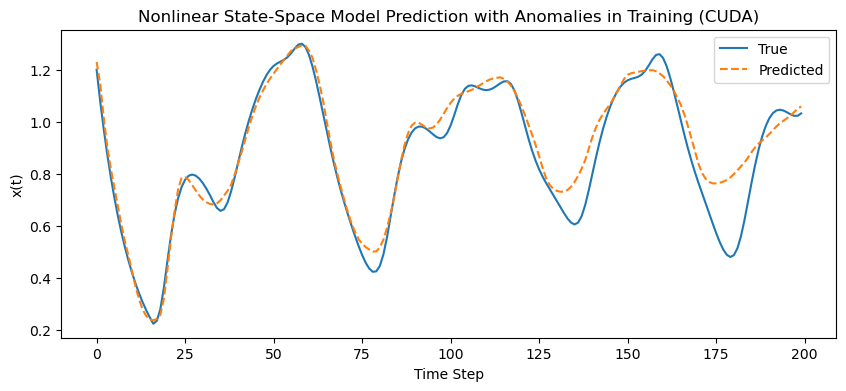

In [19]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
import matplotlib.pyplot as plt
import random
# --- Use GPU if available ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
# --- 1. Fix Python, NumPy, and random seeds ---
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# --- 2. Force deterministic behavior for cuDNN ---
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# --- Mackey-Glass Generator ---
def mackey_glass(t_max, tau=17, delta_t=1, beta=0.2, gamma=0.1, n=10, x0=1.2):
    t_len = int(t_max / delta_t)
    x = np.zeros(t_len)
    x[0] = x0
    for t in range(1, t_len):
        if t - tau >= 0:
            x[t] = x[t - 1] + delta_t * (
                beta * x[t - tau] / (1 + x[t - tau] ** n) - gamma * x[t - 1]
            )
        else:
            x[t] = x[t - 1] - delta_t * gamma * x[t - 1]
    return x

# --- Function to insert anomalies ---
def insert_anomalies(x, anomaly_rate=0.1, anomaly_scale=0.7):
    x_anom = x.copy()
    n_points = len(x)
    n_anomalies = int(n_points * anomaly_rate)
    anomaly_indices = np.random.choice(n_points, size=n_anomalies, replace=False)
    for idx in anomaly_indices:
        x_anom[idx] += np.random.uniform(-anomaly_scale, anomaly_scale)
    return x_anom

# --- Parameters ---
t_max = 200
delta_t = 1
train_ics_left = np.linspace(0, 1.17, 15)
train_ics_right = np.linspace(1.23, 3, 15)
train_ics = np.concatenate((train_ics_left, train_ics_right))
test_ic = 1.2
timesteps = np.arange(0, t_max, delta_t)

# --- Generate training data with anomalies ---
X_list, y_list = [], []
n_anomalous = 5
anomalous_indices = [15, 5, 23, 7, 18]

for i, ic in enumerate(train_ics):
    x = mackey_glass(t_max=t_max, x0=ic)
    if i in anomalous_indices:
        x = insert_anomalies(x, anomaly_rate=0.1, anomaly_scale=0.7)
    norm_t = timesteps / t_max
    features = np.stack([np.full_like(norm_t, ic), norm_t], axis=1)
    X_list.append(features)
    y_list.append(x)

X = np.vstack(X_list)
y = np.concatenate(y_list)

# --- Generate test data ---
x_test = mackey_glass(t_max=t_max, x0=test_ic)
norm_t_test = timesteps / t_max
X_test = np.stack([np.full_like(norm_t_test, test_ic), norm_t_test], axis=1)
y_test = x_test

# --- Normalize features ---
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

# --- Convert to tensors and move to device ---
X_tensor = torch.tensor(X_scaled, dtype=torch.float32).reshape(len(train_ics), t_max, 2).to(device)
y_tensor = torch.tensor(y, dtype=torch.float32).reshape(len(train_ics), t_max).to(device)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).unsqueeze(0).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(0).to(device)

# --- Split train/val ---
val_split = 4
train_len = len(train_ics) - val_split
train_dataset, val_dataset = random_split(TensorDataset(X_tensor, y_tensor), [train_len, val_split])
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4)

# --- Nonlinear State-Space Model ---
class NonlinearSSM(nn.Module):
    def __init__(self, state_size=128, input_size=2, hidden_size=256):
        super(NonlinearSSM, self).__init__()
        # State transition
        self.f = nn.Sequential(
            nn.Linear(state_size + input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, state_size),
            nn.Tanh()
        )
        # Observation / readout
        self.g = nn.Sequential(
            nn.Linear(state_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size//2),
            nn.ReLU(),
            nn.Linear(hidden_size//2, 1)
        )
        self.state_size = state_size

    def forward(self, u_seq):
        T = u_seq.shape[1]
        batch = u_seq.shape[0]
        x = torch.zeros(batch, self.state_size, device=u_seq.device)  # move latent state to same device
        y_pred = []
        for t in range(T):
            u_t = u_seq[:, t, :]
            x = self.f(torch.cat([x, u_t], dim=1))
            y_t = self.g(x)
            y_pred.append(y_t)
        y_pred = torch.stack(y_pred, dim=1).squeeze(-1)
        return y_pred

# --- Training ---
model = NonlinearSSM().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

epochs = 200
best_val_loss = float('inf')
patience = 40
patience_counter = 0
best_state = None

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        y_pred = model(xb)
        loss = criterion(y_pred, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            y_pred = model(xb)
            val_loss += criterion(y_pred, yb).item()
    val_loss /= len(val_loader)

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_state = model.state_dict()
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    if epoch % 10 == 0 or epoch == epochs-1:
        print(f"Epoch {epoch}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

# --- Load best model ---
model.load_state_dict(best_state)

# --- Predict on test ---
model.eval()
with torch.no_grad():
    pred_test = model(X_test_tensor).squeeze(0).cpu().numpy()

# --- Plot ---
plt.figure(figsize=(10,4))
plt.plot(y_test, label="True")
plt.plot(pred_test, '--', label="Predicted")
plt.title("Nonlinear State-Space Model Prediction with Anomalies in Training (CUDA)")
plt.xlabel("Time Step")
plt.ylabel("x(t)")
plt.legend()
plt.show()



Test RMSE: 0.0783
Test R²:   0.9136


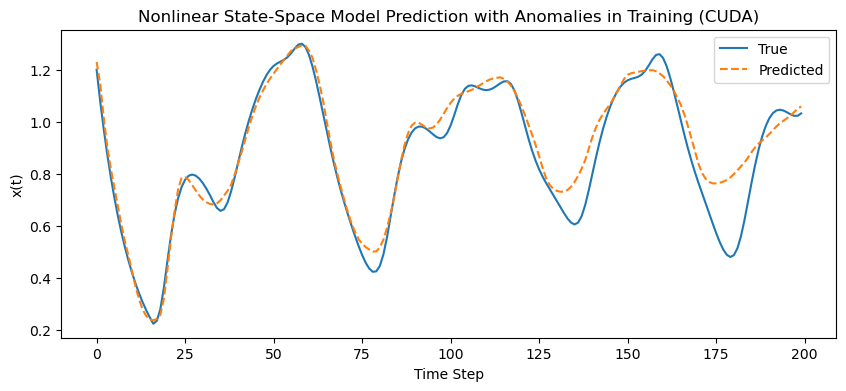

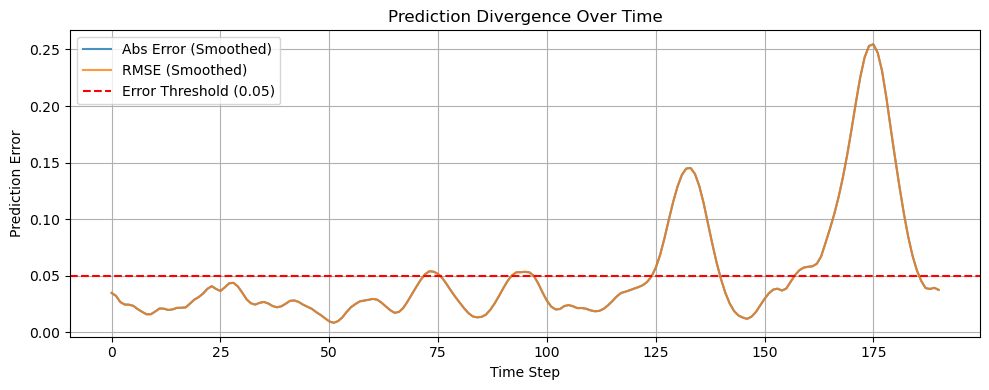

Prediction horizon at threshold 0.05: 72 steps


In [22]:
from sklearn.metrics import mean_squared_error, r2_score


rmse = np.sqrt(mean_squared_error(y_test, pred_test))
r2 = r2_score(y_test, pred_test)
print(f"\nTest RMSE: {rmse:.4f}")
print(f"Test R²:   {r2:.4f}")

# --- Plot ---
plt.figure(figsize=(10,4))
plt.plot(y_test, label="True")
plt.plot(pred_test, '--', label="Predicted")
plt.title("Nonlinear State-Space Model Prediction with Anomalies in Training (CUDA)")
plt.xlabel("Time Step")
plt.ylabel("x(t)")
plt.legend()
plt.show()


# Divergence
errors = np.abs(pred_test - y_test)            # abs error
rmse_window = np.sqrt((pred_test - y_test)**2) # RMSE error

# Optional: smooth with moving average for clarity
def moving_avg(x, w=10):
    return np.convolve(x, np.ones(w)/w, mode='valid')

window_size = 10
smoothed_error = moving_avg(errors, w=window_size)
smoothed_rmse = moving_avg(rmse_window, w=window_size)

# Plot
plt.figure(figsize=(10, 4))
plt.plot(smoothed_error, label="Abs Error (Smoothed)", alpha=0.8)
plt.plot(smoothed_rmse, label="RMSE (Smoothed)", alpha=0.8)
plt.axhline(y=0.05, color='r', linestyle='--', label='Error Threshold (0.05)')
plt.title("Prediction Divergence Over Time")
plt.xlabel("Time Step")
plt.ylabel("Prediction Error")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

threshold = 0.05
divergence_time = np.argmax(smoothed_error > threshold)
print(f"Prediction horizon at threshold {threshold}: {divergence_time} steps")

In [24]:
from scipy.stats import pearsonr, spearmanr

def correlation_metrics(y_true, y_pred):
    pearson_corr, _ = pearsonr(y_true, y_pred)
    spearman_corr, _ = spearmanr(y_true, y_pred)
    return pearson_corr, spearman_corr

pearson_corr, spearman_corr = correlation_metrics(y_test, pred_test)
print(f"Pearson correlation: {pearson_corr:.4f}")
print(f"Spearman correlation: {spearman_corr:.4f}")


Pearson correlation: 0.9648
Spearman correlation: 0.9636


Spectral cosine similarity: 0.9999


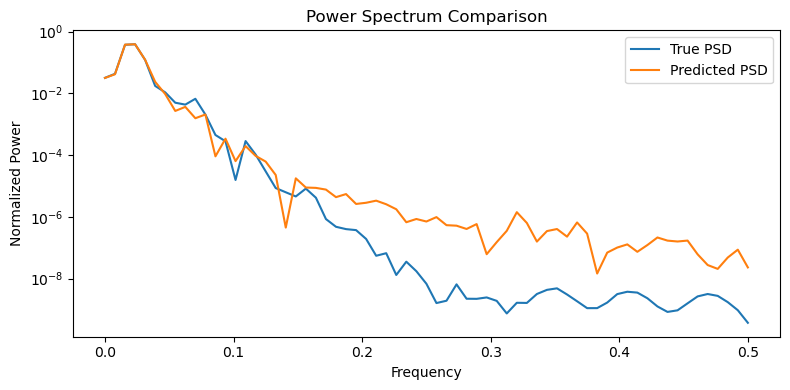

In [26]:
from scipy.signal import welch
from numpy.linalg import norm

def spectral_similarity(y_true, y_pred, fs=1.0):
    # Welch’s method for power spectral density (PSD)
    f_true, Pxx_true = welch(y_true, fs=fs, nperseg=128)
    f_pred, Pxx_pred = welch(y_pred, fs=fs, nperseg=128)

    # Normalize
    Pxx_true /= np.sum(Pxx_true)
    Pxx_pred /= np.sum(Pxx_pred)

    # Cosine similarity
    cosine_sim = np.dot(Pxx_true, Pxx_pred) / (norm(Pxx_true) * norm(Pxx_pred))
    return cosine_sim, f_true, Pxx_true, Pxx_pred

cos_sim, f, spec_true, spec_pred = spectral_similarity(y_test, pred_test)
print(f"Spectral cosine similarity: {cos_sim:.4f}")

# Plot spectra
plt.figure(figsize=(8,4))
plt.semilogy(f, spec_true, label="True PSD")
plt.semilogy(f, spec_pred, label="Predicted PSD")
plt.title("Power Spectrum Comparison")
plt.xlabel("Frequency")
plt.ylabel("Normalized Power")
plt.legend()
plt.tight_layout()
plt.show()


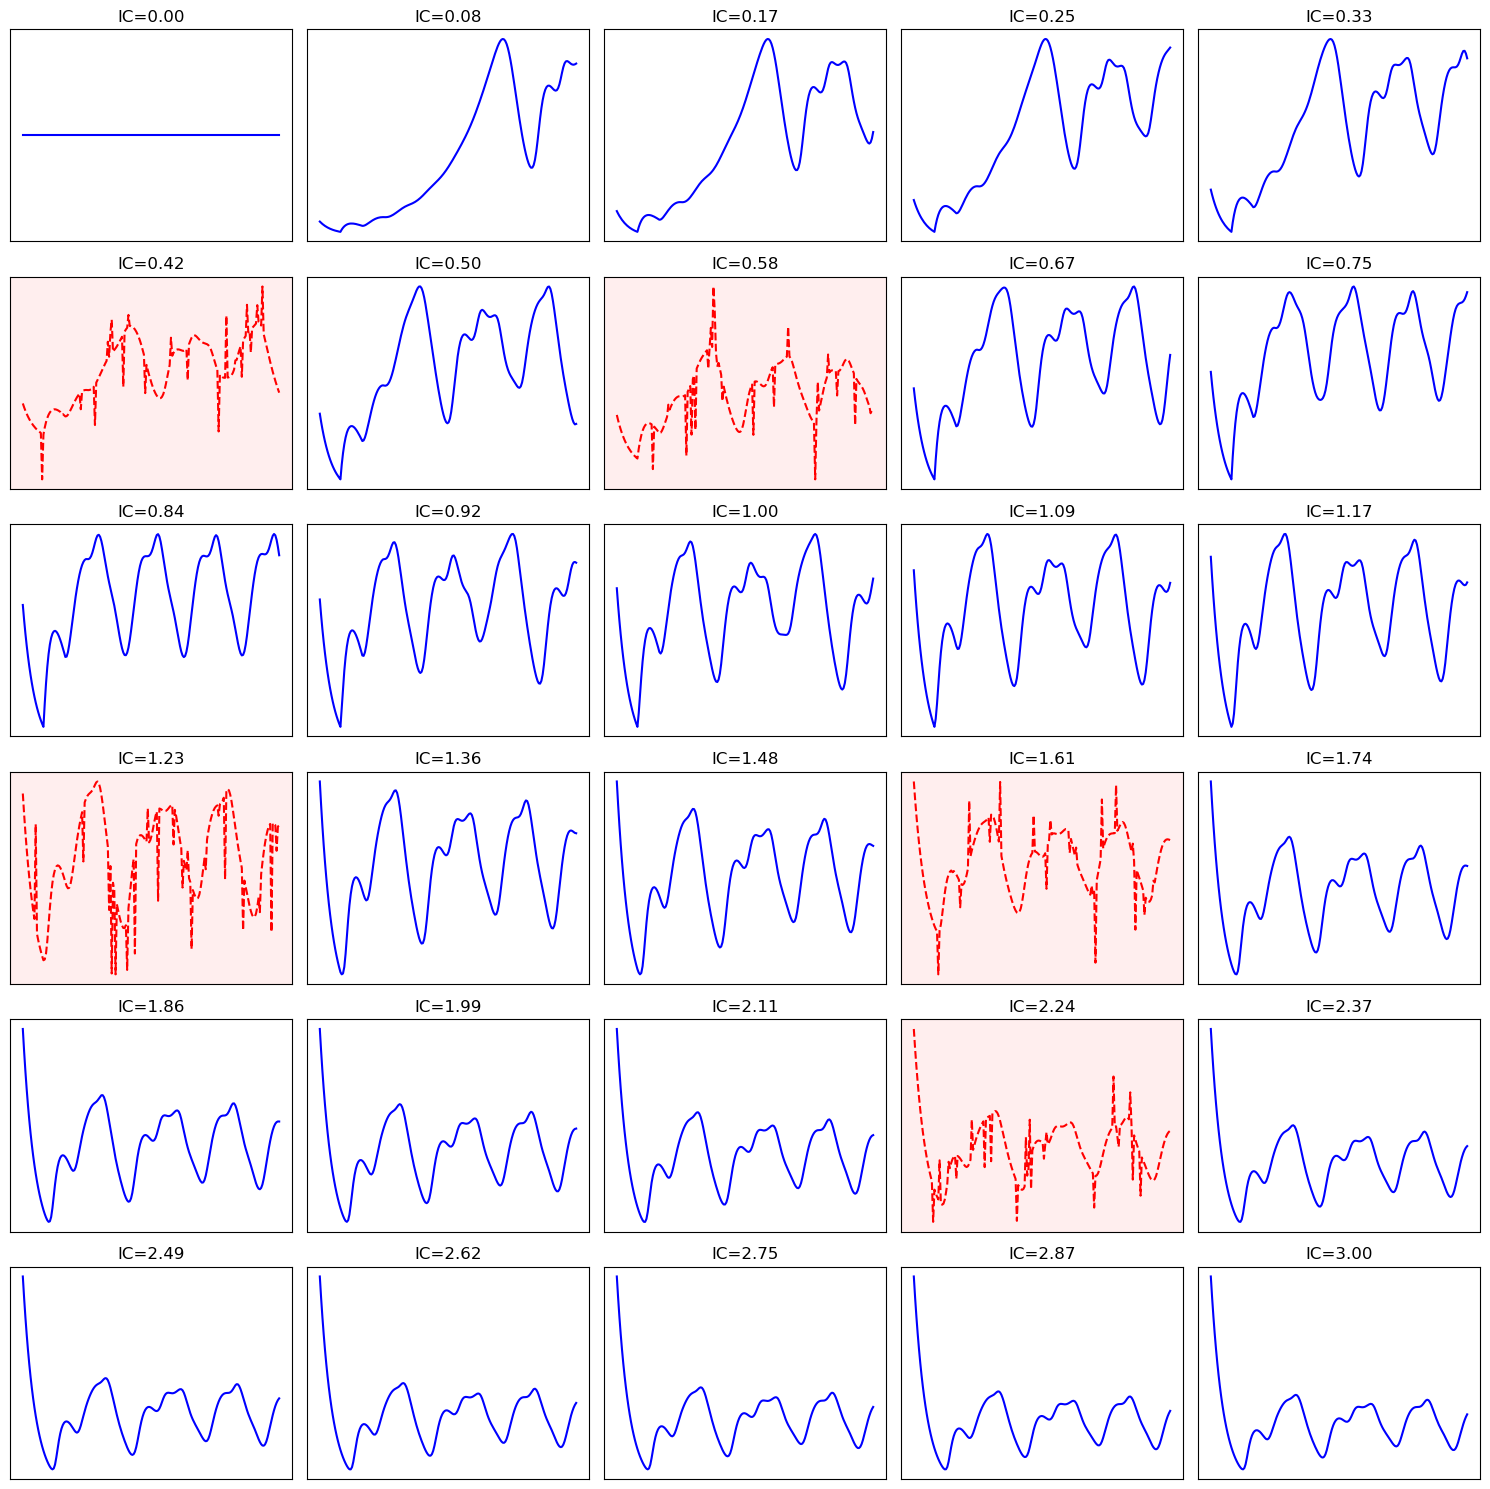

In [17]:
import math

# Number of rows and columns for subplot grid
n_traj = len(y_list)
n_cols = 5  # you can change this
n_rows = math.ceil(n_traj / n_cols)

plt.figure(figsize=(n_cols*3, n_rows*2.5))

for i, x in enumerate(y_list):
    plt.subplot(n_rows, n_cols, i+1)
    if i in anomalous_indices:
        plt.plot(x, 'r--', label=f"IC={train_ics[i]:.2f} (Anomalous)")
    else:
        plt.plot(x, 'b-', label=f"IC={train_ics[i]:.2f}")
    plt.title(f"IC={train_ics[i]:.2f}")
    plt.xticks([])
    plt.yticks([])
    if i in anomalous_indices:
        plt.gca().set_facecolor("#ffeeee")  # light red background for anomalies

plt.tight_layout()
plt.show()

Test RMSE: 0.0783
Test R²:   0.913
Pearson correlation: 0.9648
Spearman correlation: 0.963
Spectral cosine similarity: 0.999966

In [28]:
from scipy.stats import f as f_dist

# --- F-statistic and p-value ---
n = len(y_test)
k = X_test.shape[1]  # number of predictors = 2
F_stat = (r2 / k) / ((1 - r2) / (n - k - 1))
p_value = 1 - f_dist.cdf(F_stat, k, n - k - 1)

print(f"F-statistic: {F_stat:.4f}")
print(f"P-value:     {p_value:.4e}")

print(f"Total Runtime: {end_time - start_time:.2f} seconds")

F-statistic: 1041.3145
P-value:     1.1102e-16


NameError: name 'end_time' is not defined